## DrainEye -- детекция дефектов дренажа

**Цель:** обучить модель детекции объектов YOLOv8s на датасете `draineye-defects` для локализации и классификации дефектов `corrosion` и `crack` с экспортом в TFLite-формат.

## Установка зависимостей
**Цель:** установить `roboflow` для загрузки датасета и `ultralytics` для обучения YOLOv8. Версии зафиксированы для воспроизводимости.

In [ ]:
!pip install roboflow==1.3.6 ultralytics==8.4.0 tensorflow==2.20.0 numpy==2.0.2

## Воспроизводимость
**Цель:** зафиксировать `PYTHONHASHSEED` до любых импортов -- это единственный способ контролировать хэш-рандомизацию Python. Установка после импортов не дает эффекта.

In [ ]:
import os
os.environ['PYTHONHASHSEED'] = "42"

## Подключение Google Drive
**Цель:** смонтировать Google Drive для сохранения датасета, весов модели и артефактов обучения. Drive монтируется до загрузки датасета -- иначе путь не существует.

In [ ]:
from google.colab import userdata, drive

drive.mount("/content/drive")

## Импорты
**Цель:** подключить все необходимые библиотеки -- для работы с данными, визуализации результатов обучения, инференса через TensorFlow Lite и детекции через Ultralytics YOLO.

In [ ]:
import random
import yaml

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from ultralytics import YOLO

from roboflow import Roboflow

%matplotlib inline

## Конфигурация
**Цель:** задать все параметры эксперимента в одном месте.

In [ ]:
WORKSPACE = "draineye"
PROJECT_NAME = "draineye-defects"
PROJECT_VERSION = 1
MODEL_ARCH = "yolov8"
MODEL_TYPE = "yolov8s"

DATA_DIR = "/content/drive/MyDrive/draineye-detection"

MODEL_NAME = "model_v" + str(PROJECT_VERSION)
MODEL_DIR = DATA_DIR + "/" + MODEL_NAME

SEED = 42
EPOCHS = 120
TUNE_EPOCHS = 30
TUNE_ITERATIONS = 20

IMG_SIZE = (640, 640)

## Загрузка датасета
**Цель:** скачать датасет `draineye-defects` с Roboflow в формате YOLOv8 (bbox-аннотации). Датасет содержит классы `corrosion` и `crack`. API-ключ читается из секретов Colab.

In [ ]:
rf = Roboflow(api_key=userdata.get("ROBOFLOW_API_KEY"))
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
version = project.version(PROJECT_VERSION)
dataset = version.download(MODEL_ARCH, location=f"{DATA_DIR}/cache")

loading Roboflow workspace...
loading Roboflow project...


## Проверка конфигурации датасета
**Цель:** убедиться что `data.yaml` корректно описывает классы и пути к сплитам. Это позволяет поймать ошибки конфигурации до запуска обучения.

In [ ]:
with open(f"{DATA_DIR}/cache/data.yaml") as f:
  data = yaml.safe_load(f)

data

{'names': ['corrosion', 'crack'],
 'nc': 2,
 'roboflow': {'license': 'CC BY 4.0',
  'project': 'draineye-defects',
  'url': 'https://universe.roboflow.com/draineye/draineye-defects/dataset/1',
  'version': 1,
  'workspace': 'draineye'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

## Обучение модели
**Цель:** обучить YOLOv8s на задачу детекции дефектов. Используется cosine LR schedule (`cos_lr=True`, `lrf=0.1`) для плавного снижения learning rate и предотвращения переобучения. `patience=15` остановит обучение если 15 эпох подряд нет улучшения.

In [ ]:
model = YOLO(f"{MODEL_TYPE}.pt")

model.train(
    data=f"{DATA_DIR}/cache/data.yaml",
    imgsz=IMG_SIZE[0],

    epochs=EPOCHS,
    seed=SEED,

    cos_lr=True,
    lrf=0.1,
    patience=15,

    project=DATA_DIR,
    name=MODEL_NAME
)

## Тюнинг гиперпараметров
**Цель:** автоматически перебрать гиперпараметры чтобы найти лучшую комбинацию. Каждая итерация -- отдельная мини-тренировка на `TUNE_EPOCHS` эпох. `plots=False, save=False` ускоряют процесс, не сохраняя промежуточные артефакты.

In [ ]:
model = YOLO(f"{MODEL_DIR}/weights/best.pt")
model.tune(
    data=f"{DATA_DIR}/cahce/data.yaml",
    epoch=TUNE_EPOCHS,
    iterations=TUNE_ITERATIONS,
    imgsz=IMG_SIZE[0],
    plots=False,
    save=False,
    val=True
)

## Вспомогательная функция визуализации
**Цель:** вынести отображение графиков в отдельную функцию чтобы не дублировать код при визуализации результатов обучения.

In [ ]:
def show_image(path: str) -> None:
  fig = plt.figure(figsize=(16, 8))
  img = mpimg.imread(path)
  imgplot = plt.imshow(img)
  plt.show()

## Кривые обучения
**Цель:** визуализировать динамику train/val losses и метрик (`mAP50`, `Precision`, `Recall`) по эпохам. Позволяет выявить переобучение -- val loss растёт пока train loss снижается.

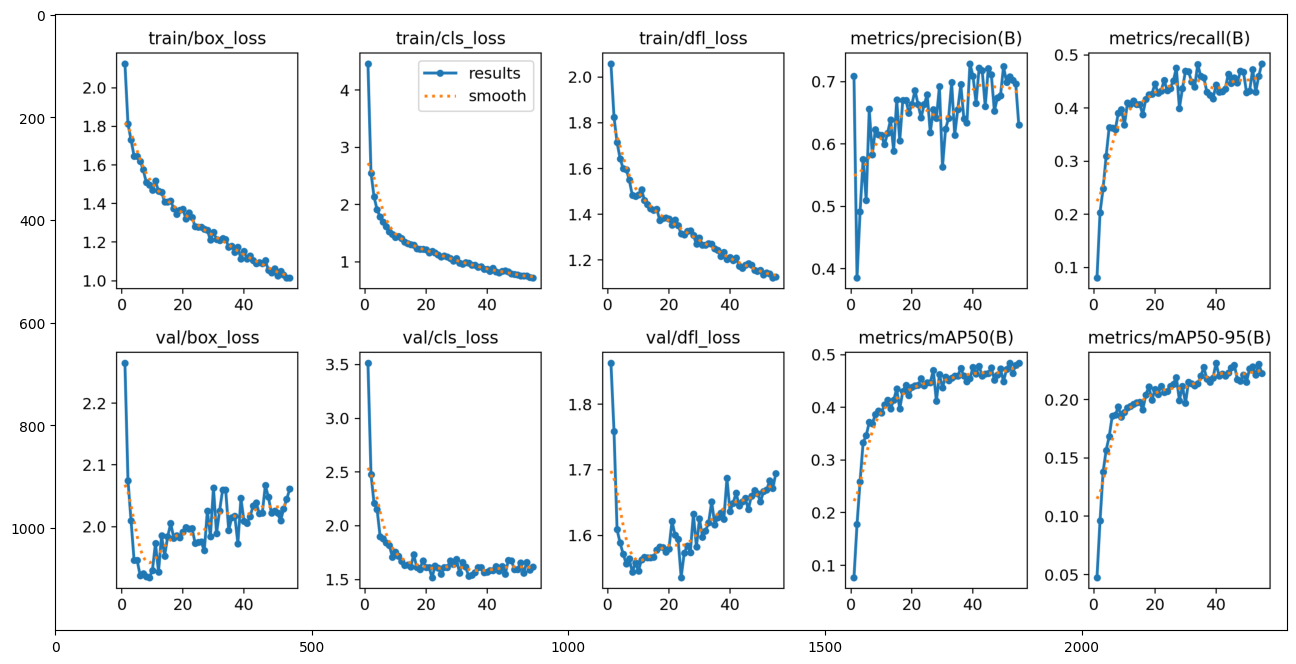

In [ ]:
results_img = show_image(f"{MODEL_DIR}/results.png")

**Результаты:**
- train losses стабильно снижаются
- val/box_loss и val/dfl_loss растут с ~эпохи 10 -- признак переобучения на локализации
- val/cls_loss стабилен -- классификация обобщает нормально
- mAP50 достигает плато ~0.475

## Матрица ошибок
**Цель:** оценить качество детекции по классам. Показывает сколько объектов каждого класса модель нашла корректно, пропустила (FN) или ошиблась классом (FP).

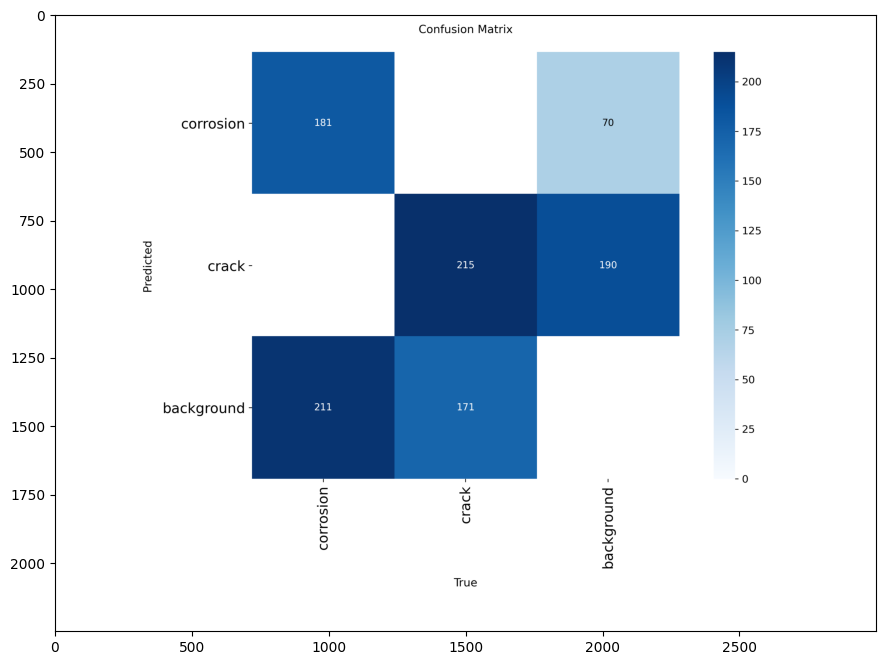

In [ ]:
conf_matrix_img = show_image(f"{MODEL_DIR}/confusion_matrix.png")

**Результаты:**
- corrosion: 181 правильно, 211 пропущено (FN) -- низкий recall
- crack: 215 правильно, 171 пропущено (FN)
- 70 corrosion и 190 crack предсказаны как background -- модель недоуверена
- Путаницы между классами нет (0 в off-diagonal) -- классификация корректная, проблема в детекции

## Precision-Recall кривая
**Цель:** оценить компромисс между точностью и полнотой при разных порогах уверенности. Площадь под кривой (`mAP50`) -- основная метрика качества детектора.

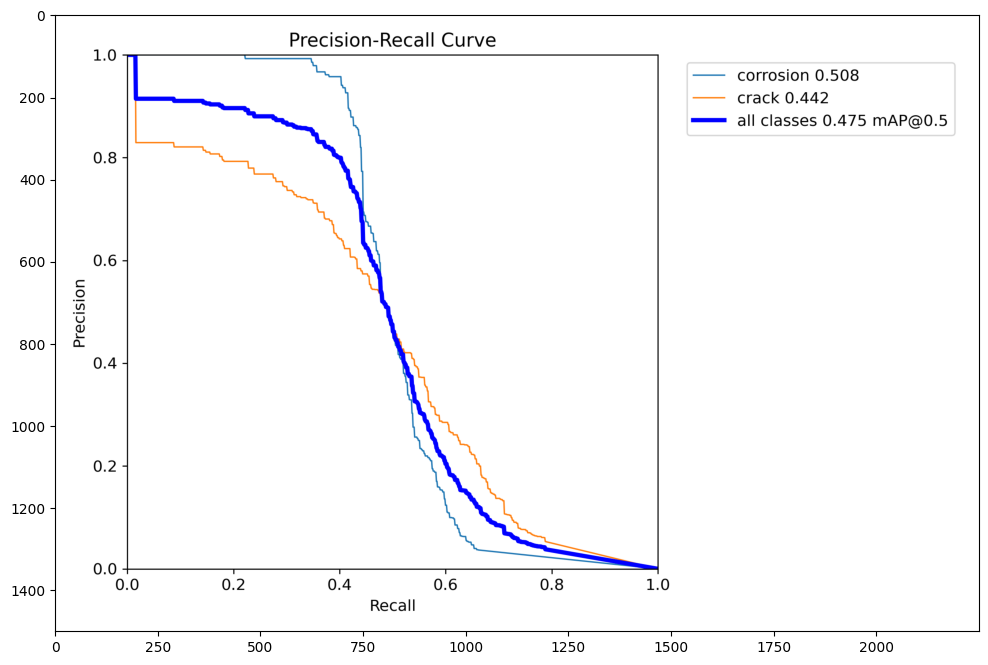

In [ ]:
pr_curve_img = show_image(f"{MODEL_DIR}/BoxPR_curve.png")

**Результаты:**
- corrosion mAP50 = 0.508 > crack mAP50 = 0.442
- Обе кривые резко падают после recall ~0.5 -- модель находит ~половину дефектов
- При высокой уверенности (низкий recall) precision высокая -- модель точная но пропускает много

## Экспорт в TFLite (базовый)
**Цель:** конвертировать лучшие веса `.pt` в TFLite формат для инференса. `nms=True` встраивает Non-Maximum Suppression в граф модели -- Flutter получает уже отфильтрованные bbox без необходимости реализовывать NMS вручную.

In [ ]:
best_model = YOLO(f"{MODEL_DIR}/weights/best.pt")
best_model.export(format="tflite", imgsz=IMG_SIZE[0], nms=True)

## Обертка модели с препроцессингом
**Цель:** встроить нормализацию пикселей (`/255.0`) и resize до `640x640` прямо в граф модели.

Использован подход subclassing (`tf.keras.Model`) вместо Functional API, так как SavedModel от Ultralytics вызывается через `signatures["serving_default"]` и несовместим с символическими тензорами Keras.

In [ ]:
class YOLOWithPreprocess(tf.keras.Model):
    def __init__(self, yolo_model):
        super().__init__()
        self.yolo = yolo_model
        self.resize = tf.keras.layers.Resizing(640, 640)
        self.rescale = tf.keras.layers.Rescaling(scale=1./255)

    def call(self, inputs):
        x = self.resize(inputs)
        x = self.rescale(x)
        return self.yolo.signatures["serving_default"](images=x)['output_0']

keras_model = tf.saved_model.load(f"{MODEL_DIR}/weights/best_saved_model")
final_model = YOLOWithPreprocess(keras_model)

## Экспорт в TFLite с препроцессингом
**Цель:** конвертировать обернутую модель в финальный TFLite файл. Результирующий файл принимает `uint8 [1, 640, 640, 3]` и возвращает `float32 [1, 300, 6]` -- формат `[x1, y1, x2, y2, conf, class_id]` с нормализованными координатами `[0, 1]`.

In [ ]:
dummy = np.zeros((1, 640, 640, 3), dtype=np.uint8)
_ = final_model(dummy)

converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
tflite_model = converter.convert()

with open(f"{MODEL_DIR}/weights/{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)